<a href="https://colab.research.google.com/github/aot-abhishekyadav/Machine-Learning-Fundamentals/blob/main/13-Binning/binning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Hum** **binning** **and** **binarization** **ki** **help** **sai** **numerical** **value** **ko** **categorical** **value** **mai** **convert** **karte** **hai**

### *ques* .Why we have to convert numerical value to categorical value when numerical value perform better in model

Ans . There are some cases in real life where categorical value perform better.

      for e.g. :- playstore pai famous apps ko 10 lakh sai bhi jaada logo nai downlaod kar rkha hota hai aur vhi jo app
      famous nhi hote unko 50 logo nai downlaod kar rkha hota hai to aise hum jab graph banate hai to vo bhut right
      skewed graph ban jaata hai kyuki bhut app kai downloader bhut jaad ahai aur bhut app kai bhut kam hai. To hum
      aisi jgh inn numerical values ko categorical value mai convert kar dete hai by using 'BINS'

      e.g :- 100+ , 10k+, 1M+ Downloader aise convert kar dete hai.

## Doing These There Are Two Types :-

 1. Binning (Discretization)  isme hum continuous value ko dicrete mai convertr karte hai
 2. Binarization  isme hum continuous value ko Binary (0,1) mai convert karte hai

### 1. Binning(Discretization)

Binning means converting continuous numerical values into discrete intervals (bins).
Instead of using exact values, we divide them into groups.

### Why use Binning

1. To handle Outliers
2. To improve the value speed

3. Reduces noise

4. Makes model easier to understand

5. Useful for Decision Trees

for e.g. -: Age : 23,42. 10, 5, 57, ----- 100

0-10 = 5 , 10-20 = 6 , 20-30 = 10 -----

## Types of Discretization
### 1. Unsupervised

1.  Equal Width (Uniform)

2.  Equal Frequency(Quantile)

3.  K means binning

### 2. Supervise

1. Desion Tree Binning (less use)

### 3. Custom Binning

## 1. Equal Width Binning





The whole range is divided into equal-sized intervals.

Formula

Bin Width  =
Maximum−Minimum / Number of Bins

Example

Data:
10 20 30 40 50 60 70 80 90

3 bins

Range = 90-10 = 80

Width = 80/3 = 26.67

Bins

10-36.67

36.67-63.34

63.34-90

###Advantages
1.  Simple

2. Fast

###Disadvantages

1. Unequal number of samples in each bin

2. Sensitive to outliners


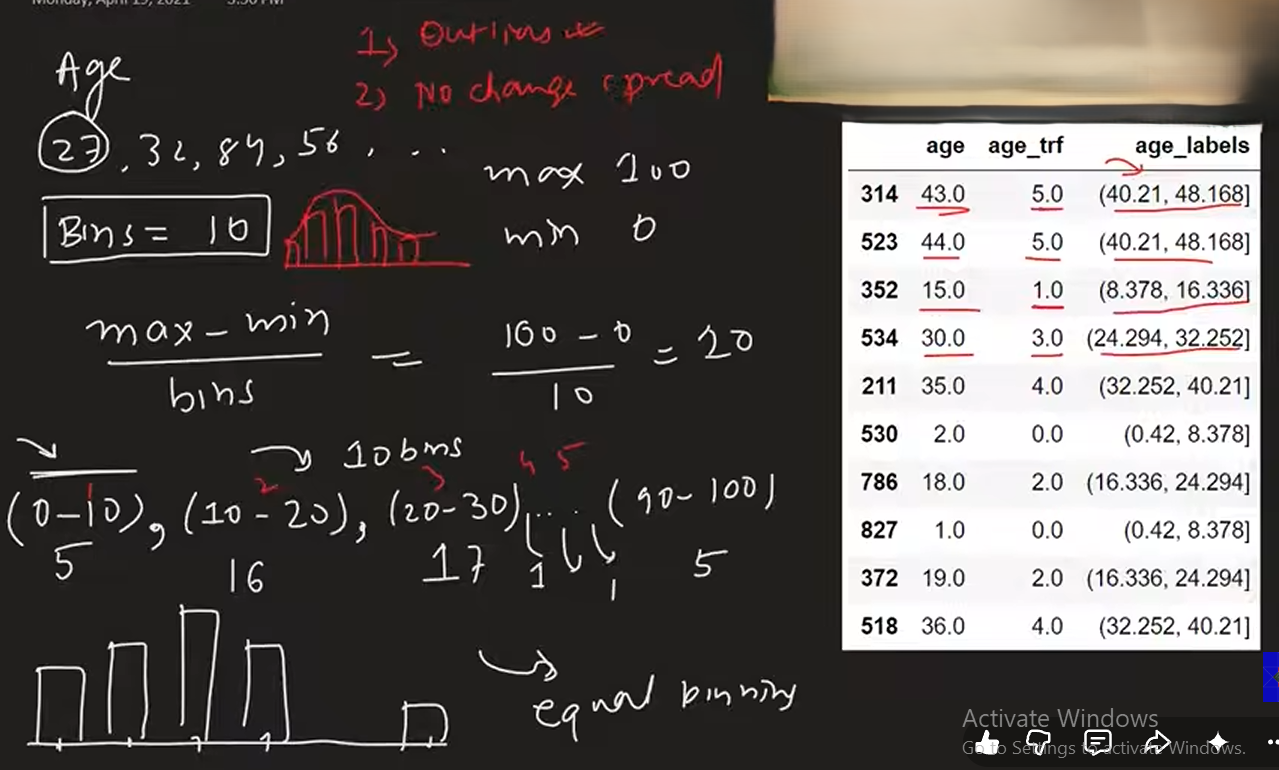

## 2. Equal Frequency/Quantile Binning

Each bin contains almost the same number of observations.

we maximum use this binning

Example

Data

10 20 30 40 50 60 70 80 90

3 bins

Bin1 :
10 20 30

Bin2 :
40 50 60

Bin3 :
70 80 90

### Advantages

1. Balanced bins
2. Less affected by outliers

###Disadvantages

1. Bin widths are different

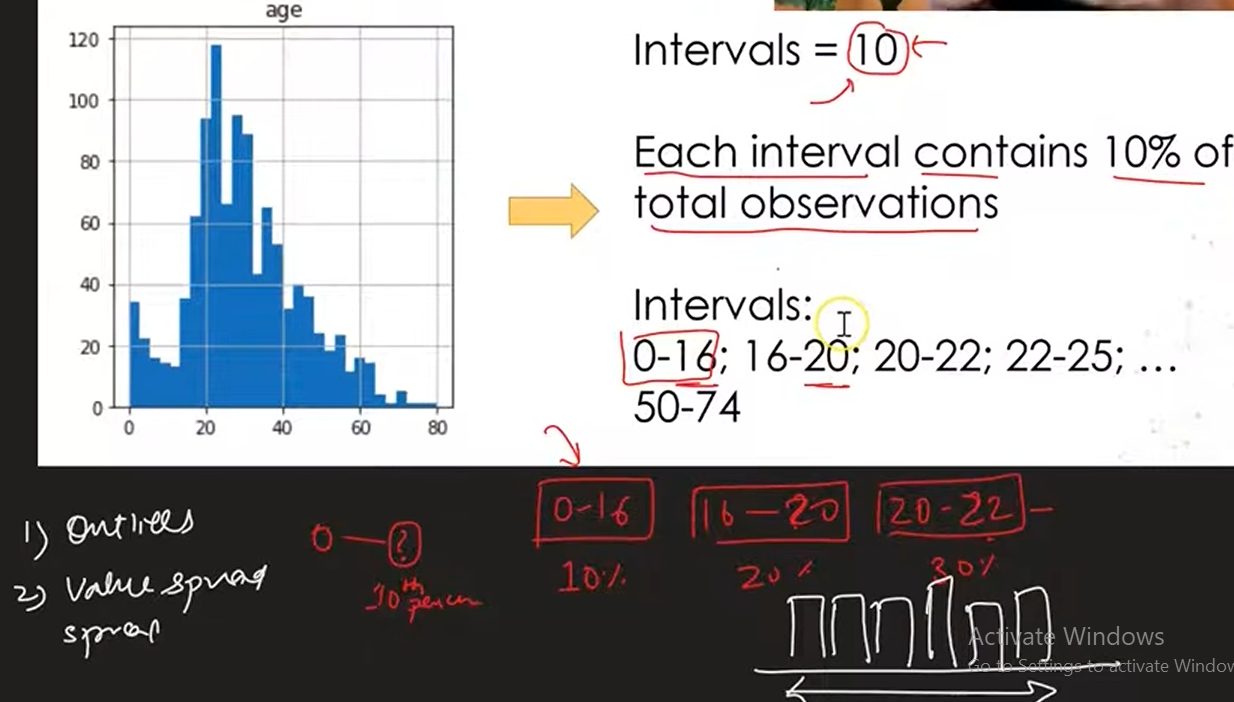


## 3. K means Binning

K-Means Binning is a feature engineering technique in which we use the K-Means clustering algorithm to divide continuous numerical data into groups (bins). Unlike Equal Width or Equal Frequency binning, the bins are created based on the similarity of data points, not fixed ranges.

How it Works

Suppose we have the following data:

5, 6, 7, 8, 50, 52, 54, 100, 102

If we choose K = 3, K-Means may create these clusters:

Cluster 1 :
5, 6, 7, 8

Cluster 2 :
50, 52, 54

Cluster 3 :
100, 102

Now each cluster acts as a bin.

                Original Data

      5   6   7   8   50   52   54   100   102
      |   |   |   |    |    |    |     |     |
      -----------------------------------------
                     K-Means (K = 3)
      -----------------------------------------
             |                 |               |
             ▼                 ▼               ▼

        Cluster 1         Cluster 2      Cluster 3
       ------------      ------------    ------------
       5                50              100
       6                52              102
       7                54
       8

             ↓                 ↓               ↓

          Bin 1             Bin 2          Bin 3

## 3. Custom Binning

User manually decides ranges.

Example

Age

0-18     Child

19-35    Adult

36-60    Middle Age

60+      Senior

Mostly used in Banking, Healthcare, Insurance.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Titanic1.csv', usecols=['Age', 'Fare', 'Survived'])

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.shape

(714, 3)

In [ ]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [ ]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
X_train.head()

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750
666,25.0,13.0000


In [ ]:
clf = DecisionTreeClassifier()

In [ ]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [ ]:
accuracy_score(y_test,y_pred)

0.6293706293706294

In [ ]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))
0.6289123630672926

0.6289123630672926

## using Binning

In [ ]:
kbin_age = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')

In [ ]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [ ]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [ ]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [ ]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [ ]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})


In [ ]:
output['age_labels'] = pd.cut(x=X_train['Age'],
                                    bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],
                                    bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [ ]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
574,16.0,2.0,8.050,3.0,"(6.0, 16.0]","(7.896, 8.158]"
417,18.0,2.0,13.000,6.0,"(16.0, 19.0]","(10.5, 13.0]"
245,44.0,12.0,90.000,13.0,"(42.0, 47.0]","(76.292, 108.9]"
12,20.0,3.0,8.050,3.0,"(19.0, 21.0]","(7.896, 8.158]"
719,33.0,9.0,7.775,2.0,"(32.0, 35.0]","(7.25, 7.775]"


In [ ]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)


In [ ]:
accuracy_score(y_test,y_pred2)

0.6363636363636364

In [ ]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6317097026604068)

In [ ]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)

    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])

    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()


0.6400821596244131


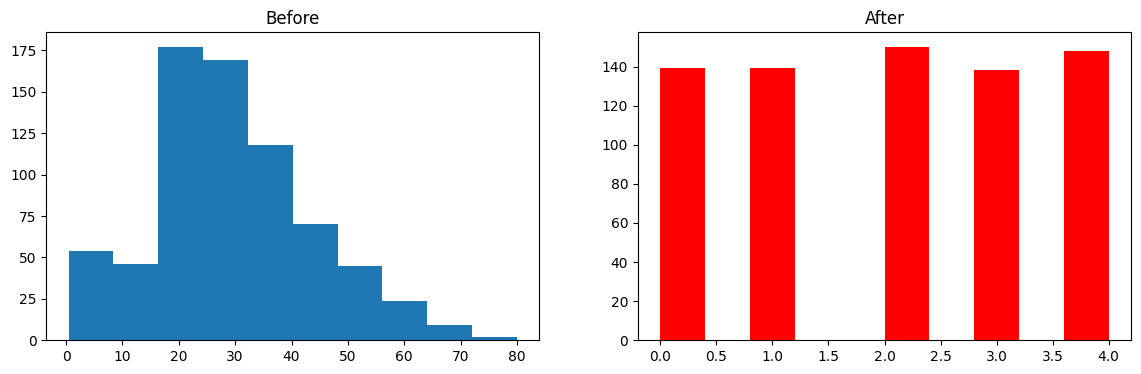

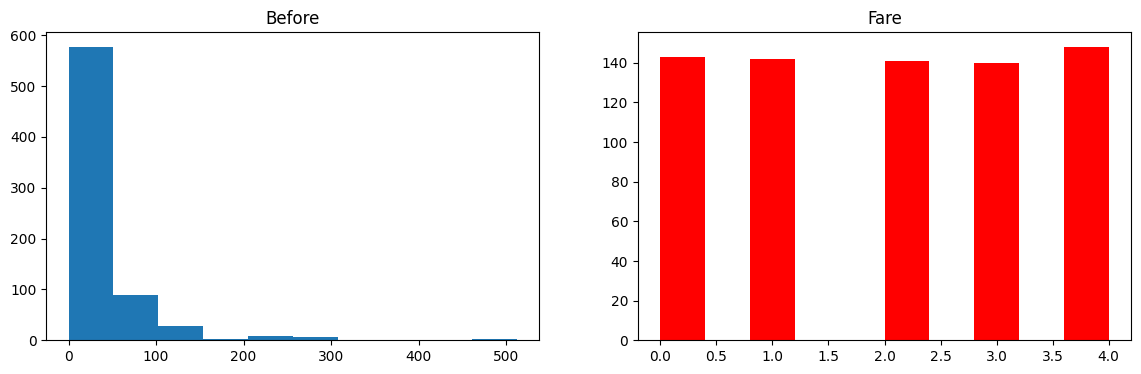

In [ ]:
discretize(5,'quantile')

0.6345461658841941


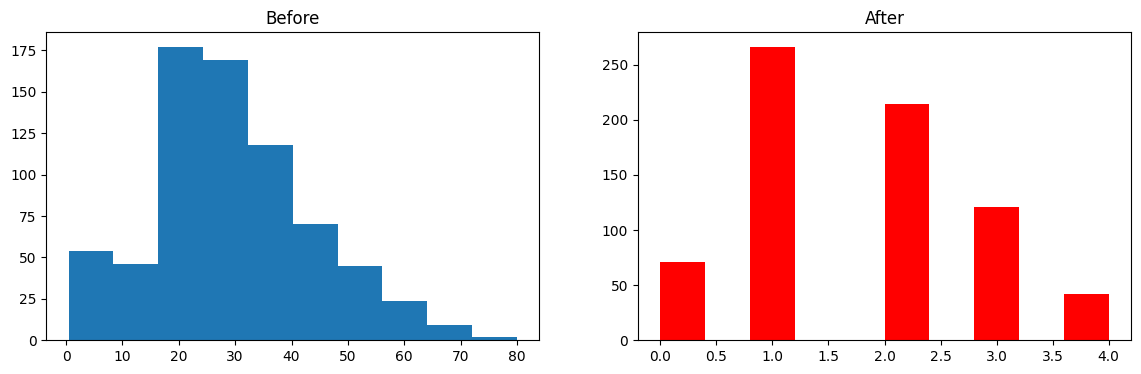

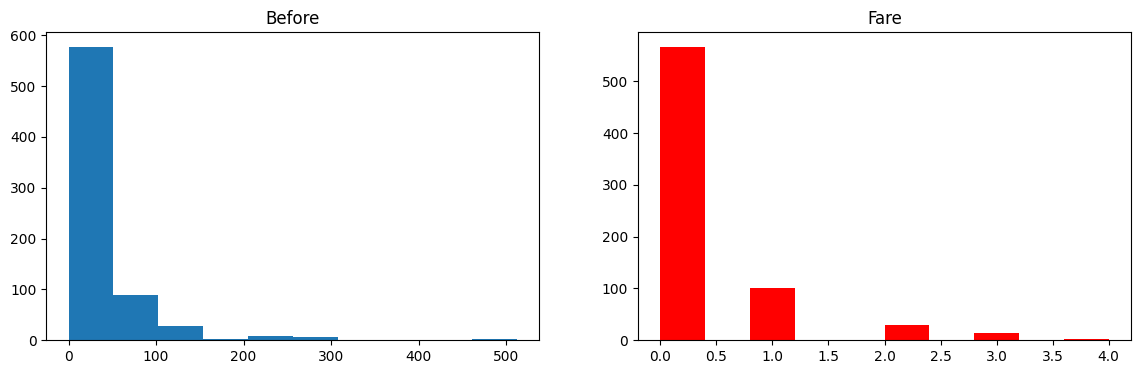

In [ ]:
discretize(5,'kmeans')

0.6260758998435054


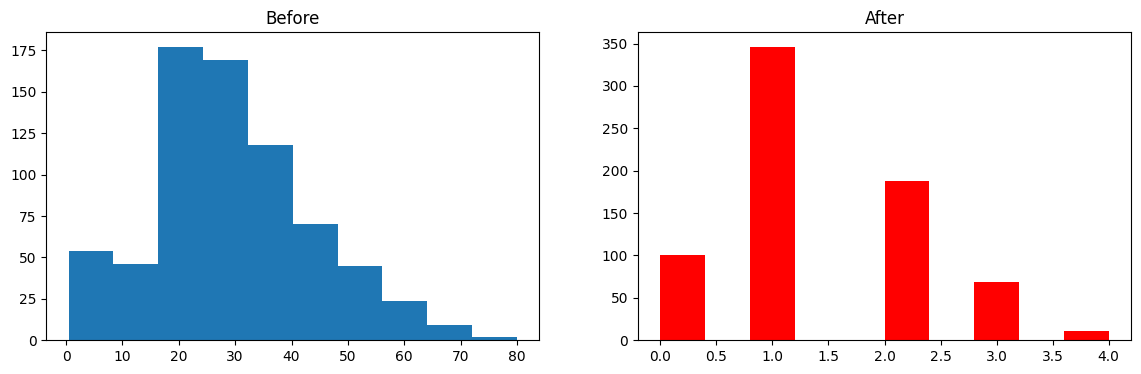

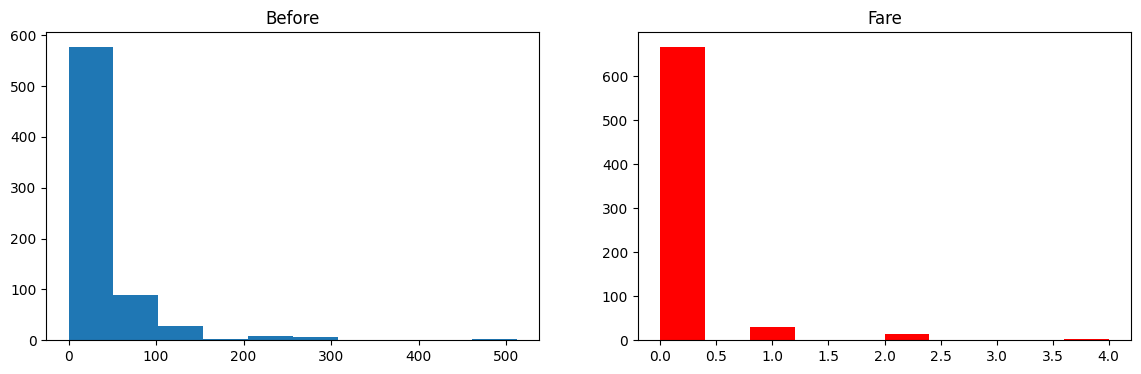

In [ ]:
discretize(5,'uniform') #